# Single Sided LBTI-NOMIC Data

This notebook is for pre-processing of single-sided LBTI-NOMIC data starting from the raw data.

In [1]:
import pyNOMIC.preprocessing as prep
import pyNOMIC.flat_methods as flat_methods
import shutil, pathlib, os
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
from tqdm.auto import tqdm

### File path

Enter directory containing raw files and the name of the object as it exists in the FITS headers.

In [2]:
raw_dir = "raw"
obj='procyon'

# Important to sort the data for reading it sequentially
raw_files = np.asarray(sorted(list(pathlib.Path(str(raw_dir)).rglob('*.fits'))))

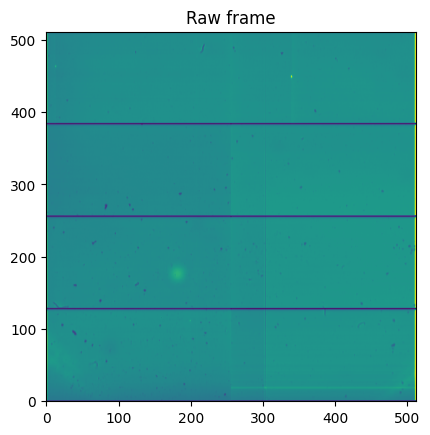

In [3]:
hdul = fits.open(raw_files[0])
plt.title("Raw frame")
plt.imshow(hdul[0].data[0], origin="lower")
hdul.close()
plt.show()

### Create badmap, temporary flat, and highpass filter mask

We first create a badmap to filter out dead pixels/columns, a temporary flat for use in chop state identification, and a highpass filter mask to avoid edge artifacts.

In [4]:
# This function creates the temporary flat and badmap
tempflat, badmap, _ = flat_methods.create_badmap(raw_files, smooth=30, sigma=1)

# We create the high pass filter mask here
highpassmask = np.ones(np.shape(badmap))
highpassmask[:30,:] = 0
highpassmask[480:,:] = 0
highpassmask[:,480:] = 0
highpassmask[:,:30] = 0

# Save all three images
hdul = fits.HDUList([fits.PrimaryHDU(data=tempflat)])
hdul.writeto(obj+"_tempflat.fits", overwrite=True)
hdul.close()

hdul = fits.HDUList([fits.PrimaryHDU(data=badmap)])
hdul.writeto(obj+"_badmap.fits", overwrite=True)
hdul.close()

hdul = fits.HDUList([fits.PrimaryHDU(data=highpassmask)])
hdul.writeto(obj+"_highpassmask.fits", overwrite=True)
hdul.close()

Creating integrated files for correlation...
Using a buffer of  330  frames...


integrating files:   0%|          | 0/1 [00:00<?, ?it/s]

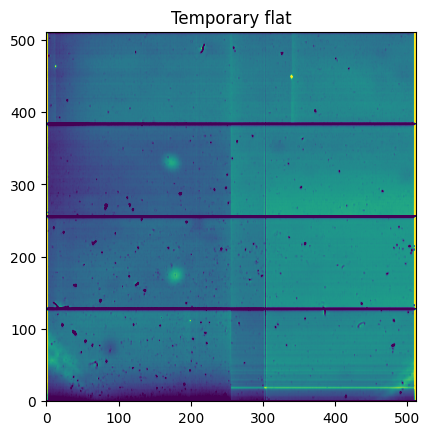

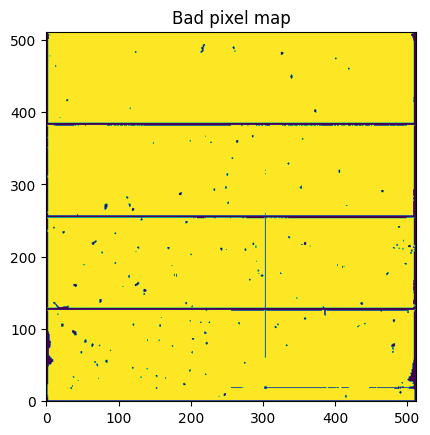

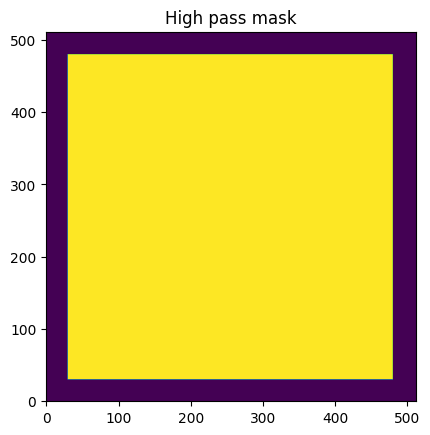

In [5]:
plt.title("Temporary flat")
plt.imshow(tempflat, origin="lower", vmin=14000, vmax=21000)
plt.show()

plt.title("Bad pixel map")
plt.imshow(badmap, origin="lower")
plt.show()

plt.title("High pass mask")
plt.imshow(highpassmask, origin="lower")
plt.show()

### Create high pass filtered frames and parallactic angles

We use the `get_data` function to create high pass filtered frames for chop identification and the parallactic angles. The chop states from the headers and frame medians are also retrieved, but are usually not useful. The images/masks from earlier are inputs into this function.

In [6]:
(uncorrected_files, 
 chops, 
 frame_medians,
 orig_para_angles, 
 highpass_dir) =\
        prep.setup_data(obj, raw_dir, skip_target_check=True, use_temp_flat=True,
                     highpassmask_dir = obj+"_highpassmask.fits", tempflat_dir=obj+"_tempflat.fits",
                        badmap_dir =obj+"_badmap.fits")

# Save to npz
np.savez(obj+"_NOMIC_getdata.npz", uncorrected_files, chops, frame_medians, orig_para_angles, highpass_dir)
print("Files saved")

Detected  330  fits files
Start frame = None
New file count =  330
Reading file headers and creating high pass filtered frames...


  0%|          | 0/330 [00:00<?, ?it/s]

Files saved


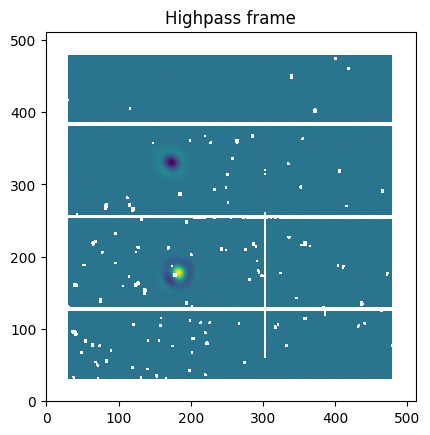

In [7]:
# Important to sort the data for reading it sequentially
highpass_files = np.asarray(sorted(list(pathlib.Path(str(highpass_dir)).rglob('*.fits'))))

hdul = fits.open(highpass_files[0])
plt.title("Highpass frame")
plt.imshow(hdul[0].data, origin="lower")
hdul.close()
plt.show()

### Identify chops and create coadded frames

Using our highpass filtered data, we identify the chop states of all the raw images and coadd any consecutive chops as necessary. We also edit our file list and parallactic angles to match the list. The coadded frames are saved in a separate directory and the file list is amended to include the coadded frames and exclude the parent raw frames.

In [8]:
files, chops, para_angles, orig_chops = prep.chop_correction(uncorrected_files,
                                                            str(highpass_dir), chops, orig_para_angles)

np.savez(obj+"_NOMIC_chop_correction.npz", files, chops, para_angles, orig_chops)
print("Files saved")

Finding chop positions....


  0%|          | 0/330 [00:00<?, ?it/s]

Finding consecutive repeat chop positions...


0it [00:00, ?it/s]

Coadding consecutive repeat chop positions...


  0%|          | 0/158 [00:00<?, ?it/s]

Files saved


### Create more flats!

The temporary flat we created earlier was a good proxy for identifying chop states, but now that we have the chop states, we can construct a better flat that omits the stellar PSF for each chop state. First, we create a "combined" flat with the function `create_stacked_flat` that uses the halves of the image from each chop state that do not have the stellar PSF and stitch them together into a single flat for the whole dataset. This flat is used to help the function `create_proper_flat` identify the PSF locations in the images so that they can be masked out. This function creates separate flats for each chop state, which will be used to calibrate the images. The neighborhood of the PSFs are replaced with the respective normalized region in the other chop state. Using separate flats is essential for combatting chop residuals, which result from path differences during chopping.

In [9]:
combined_flat = flat_methods.create_stacked_flat(files, chops, chop_direction="UP-DOWN", tolerance=0.2)

hdul = fits.HDUList([fits.PrimaryHDU(data=combined_flat)])
hdul.writeto(obj+"_combinedflat.fits", overwrite=True)
hdul.close()

Creating integrated files for correlation...
Using a buffer of  41  frames...


integrating files:   0%|          | 0/2 [00:00<?, ?it/s]

integrating files:   0%|          | 0/2 [00:00<?, ?it/s]

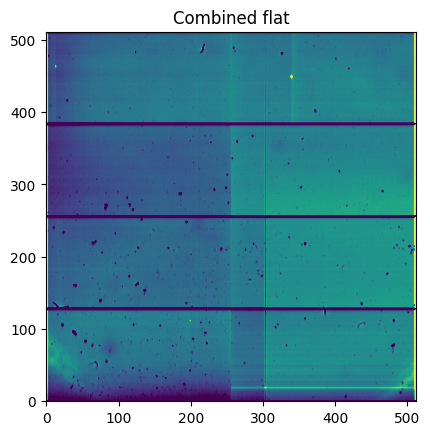

In [10]:
plt.title("Combined flat")
plt.imshow(combined_flat, origin="lower", vmin=14000, vmax=21000)
plt.show()

In [11]:
chopa_flat, chopb_flat = flat_methods.create_proper_flat(files, chops, combined_flat, inner_rad = 40, outer_rad = 44)

hdul = fits.HDUList([fits.PrimaryHDU(data=chopa_flat)])
hdul.writeto(obj+"_chopaflat.fits", overwrite=True)
hdul.close()

hdul = fits.HDUList([fits.PrimaryHDU(data=chopb_flat)])
hdul.writeto(obj+"_chopbflat.fits", overwrite=True)
hdul.close()
print("Flats saved")

Creating integrated files for correlation...
Using a buffer of  82  frames...


integrating files:   0%|          | 0/1 [00:00<?, ?it/s]

integrating files:   0%|          | 0/1 [00:00<?, ?it/s]

Flats saved


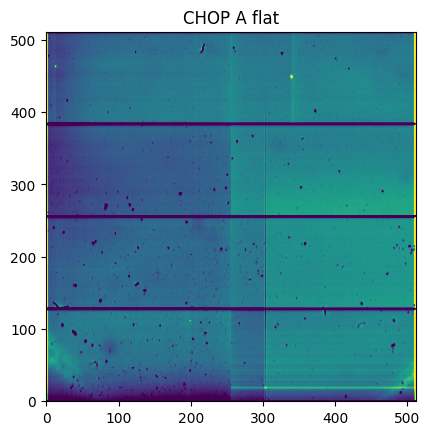

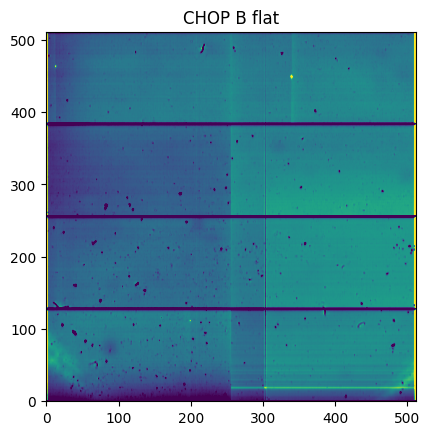

In [12]:
plt.title("CHOP A flat")
plt.imshow(chopa_flat, origin="lower", vmin=14000, vmax=21000)
plt.show()
plt.title("CHOP B flat")
plt.imshow(chopb_flat, origin="lower", vmin=14000, vmax=21000)
plt.show()

### Background subtraction

We now create background subtracted (and flat calibrated) images, with some image repair as well to deal with NOMIC systematics (striped regions, biases). These images are saved in a directory.

In [13]:
subtracted_dir = prep.subtract_background(files, chops, flats=[chopa_flat, chopb_flat],
                    striped_regions=[[0, 124, 255, 304, -3],[0, 124, 304, -3, -3]],
                        vertical_biases=[127, 255, 383],horizontal_biases=[127])

#shutil.rmtree(str(highpass_dir))

Subtracting backgrounds....


  0%|          | 0/163 [00:00<?, ?it/s]

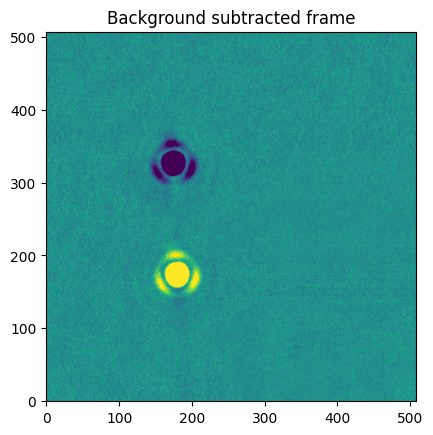

In [14]:
# Important to sort the data for reading it sequentially
subtracted_files = np.asarray(sorted(list(pathlib.Path(str(subtracted_dir)).rglob('*.fits'))))

hdul = fits.open(subtracted_files[0])
plt.title("Background subtracted frame")
plt.imshow(hdul[0].data, origin="lower", vmin=-.01, vmax=.01)
hdul.close()
plt.show()

### Frame registration
We now align the frames and place the PSFs at the center of the image. We obtain other parameters as well, including image characteristics and gaussian model fits.

In [15]:
aligned_files, original_psf_locs, reffit, array_shape, file_size = prep.frame_registration(files, subtracted_dir, nan_mask_size=2)
#shutil.rmtree(subtracted_dir)
np.savez(obj+"_NOMIC_aligned.npz", aligned_files, original_psf_locs, reffit, array_shape, file_size)
print("Files saved")

Aligning frames....


C:\Users\mmc\Music\Project\Procyon\pyNOMIC\helper_functions.py:382: RuntimeWarning: invalid value encountered in divide
  model = (amp/(1-e**2)**2) * (2*j1(rad)/rad - 2*e*j1(e*rad)/rad)**2


  0%|          | 0/161 [00:00<?, ?it/s]

Files saved


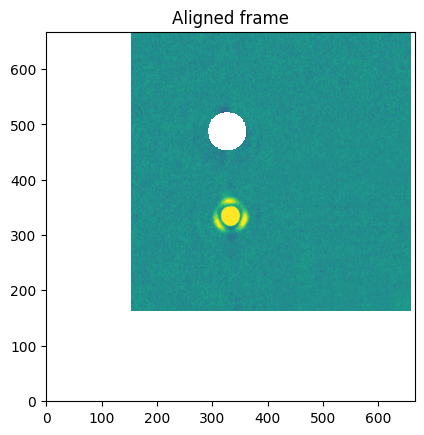

In [16]:
hdul = fits.open(aligned_files[0])
plt.title("Aligned frame")
plt.imshow(hdul[0].data, origin="lower", vmin=-.01, vmax=.01)
hdul.close()
plt.show()

### Frame evaluation
We now evaluate the frames to get properties including fwhms, background deviation, maxima, etc.

In [17]:
fwhms, eccentricities, psfmaxima, background_dev, correlations, amplitudes, gauss_offsets, sx, sy =\
                            prep.frame_evaluation(aligned_files, chops, array_shape, file_size, tolerance=0.2)
np.savez(obj+"_NOMIC_evaluated.npz", fwhms, eccentricities, psfmaxima, background_dev, correlations, amplitudes, gauss_offsets)

print("Files saved")

Creating integrated files for correlation...
Using a buffer of  20  frames...


integrating files:   0%|          | 0/4 [00:00<?, ?it/s]

C:\Users\mmc\Music\Project\Procyon\pyNOMIC\helper_functions.py:67: RuntimeWarning: Mean of empty slice
  stacked_img = np.nanmean(buf_3D, axis=0)*count


integrating files:   0%|          | 0/4 [00:00<?, ?it/s]

  0%|          | 0/163 [00:00<?, ?it/s]

Files saved


C:\Users\mmc\Music\Project\Procyon\pyNOMIC\preprocessing.py:1433: RuntimeWarning: invalid value encountered in sqrt
  eccentricities_r = np.sqrt(1 - sigmay/sigmax)


### Frame rejection and binning
We can do a first round of rejection using frame properties, and then bin the frames and obtain the binned frame properties.

In [18]:
frame_bool = prep.frame_rejection(chops, [fwhms, eccentricities, -1*psfmaxima, background_dev,
                                    -1*correlations, -1*amplitudes, gauss_offsets])
binned_files, binned_chops, binned_angles = prep.frame_binning(aligned_files, frame_bool, chops, para_angles, array_shape, bin=50)

binned_fwhms, binned_eccs, binned_psfmax, binned_backdev, binned_corrs, binned_amps, binned_gauss_offsets,\
        binned_sigmax, binned_sigmay = prep.frame_evaluation(binned_files, binned_chops, array_shape, file_size, tolerance=0.2)

np.savez(obj+"_NOMIC_binned_evaluated.npz", binned_fwhms, binned_eccs, binned_psfmax, binned_backdev, binned_corrs,
         binned_amps, binned_gauss_offsets, binned_sigmax, binned_sigmay, binned_files, binned_chops, binned_angles)
print("Files saved")

Binning files...


0it [00:00, ?it/s]

0it [00:00, ?it/s]

Creating integrated files for correlation...
Using a buffer of  2  frames...


integrating files:   0%|          | 0/1 [00:00<?, ?it/s]

integrating files:   0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/4 [00:00<?, ?it/s]

Files saved


### Frame rejection and binning
We can do a second round of rejection to obtain the final image cube.

In [19]:
binned_frame_bool = prep.frame_rejection(binned_chops, [binned_fwhms, binned_eccs, -1*binned_psfmax, binned_backdev,
                                          -1*binned_amps, binned_gauss_offsets])

image_cube = np.zeros((len(binned_files[binned_frame_bool]), array_shape[0], array_shape[1]))
for i in tqdm(range(len(image_cube))):
    hdul = fits.open(binned_files[binned_frame_bool][i])
    image_cube[i] = hdul[0].data
    hdul.close()

  0%|          | 0/4 [00:00<?, ?it/s]

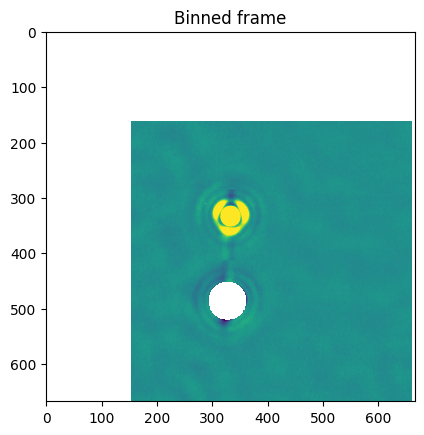

In [20]:
plt.title("Binned frame")
plt.imshow(image_cube[0], vmin=-.0001, vmax=.0001)
plt.show()